In [1]:
import pandas as pd
import numpy as np

from MATRIX.models import BaseSurvival, CoxRegression, DeepSurv, RandomSurvForest, DeepMultiTask, CoxRegressionWithTimeVarying, DeepTimeVarying
from MATRIX.utils import get_data, get_results, compute_metrics, compute_survival_metrics, compute_binary_metrics, get_xai_from_filter, save_results, format_predictions

In [2]:
%matplotlib widget

# Experiments

## Survival analysis (standard)

### Get data

In [3]:
X_train_standard, y_train_standard, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(dataset_name="colon.csv", seed=0)


- - - - colon.csv (csv) - - - -

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event         911 non-null    int64  
 1   time          911 non-null    int64  
 2   num_age       911 non-null    int64  
 3   num_nodes     911 non-null    float64
 4   fac_rx        911 non-null    object 
 5   fac_sex       911 non-null    int64  
 6   fac_differ    911 non-null    object 
 7   fac_obstruct  911 non-null    int64  
 8   fac_perfor    911 non-null    int64  
 9   fac_adhere    911 non-null    int64  
 10  fac_node4     911 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 78.4+ KB

             event         time     num_age   num_nodes fac_rx     fac_sex  \
count   911.000000   911.000000  911.000000  911.000000    911  911.000000   
unique         NaN          NaN         NaN         NaN      3         NaN   
top 

### Instantiate models

In [5]:
modelCoxRegression = CoxRegression()
modelRandomSurvForest = RandomSurvForest(0)
modelDeepSurv = DeepSurv(X_train_standard.shape[1])

### Fit and predict

In [6]:
modelCoxRegression = modelCoxRegression.fit(X_train_standard, y_train_standard)
modelRandomSurvForest = modelRandomSurvForest.fit(X_train_standard, y_train_standard)
modelDeepSurv = modelDeepSurv.fit(X_train_standard, y_train_standard)

survPredCoxRegression = modelCoxRegression.predict(X_test)
survPredRandomSurvForest = modelRandomSurvForest.predict(X_test)
survPredDeepSurv = modelDeepSurv.predict(X_test)

### Metrics

In [7]:
compute_survival_metrics(y_train_standard, y_test, survPredCoxRegression)

{'C-Index Harrel': 0.6011437635665386,
 'C-Index IPCW': 0.6102418142329669,
 'Cumulative Dinamic AUC': [0.5832670650305211,
  0.6284814887997692,
  0.6584076144438055]}

In [7]:
compute_survival_metrics(y_train_standard, y_test, survPredRandomSurvForest)

{'C-Index Harrel': 0.5966354984137585,
 'C-Index IPCW': 0.6008166074912026,
 'Cumulative Dinamic AUC': [0.5812202880191547,
  0.6243761862203789,
  0.6531895412203177]}

In [8]:
compute_survival_metrics(y_train_standard, y_test, survPredDeepSurv)

{'C-Index Harrel': 0.466563700116881,
 'C-Index IPCW': 0.45689448619995193,
 'Cumulative Dinamic AUC': [0.4988792391412787,
  0.45881951540336247,
  0.44288235114000823]}

### Survival / Cumulative Hazard Functions

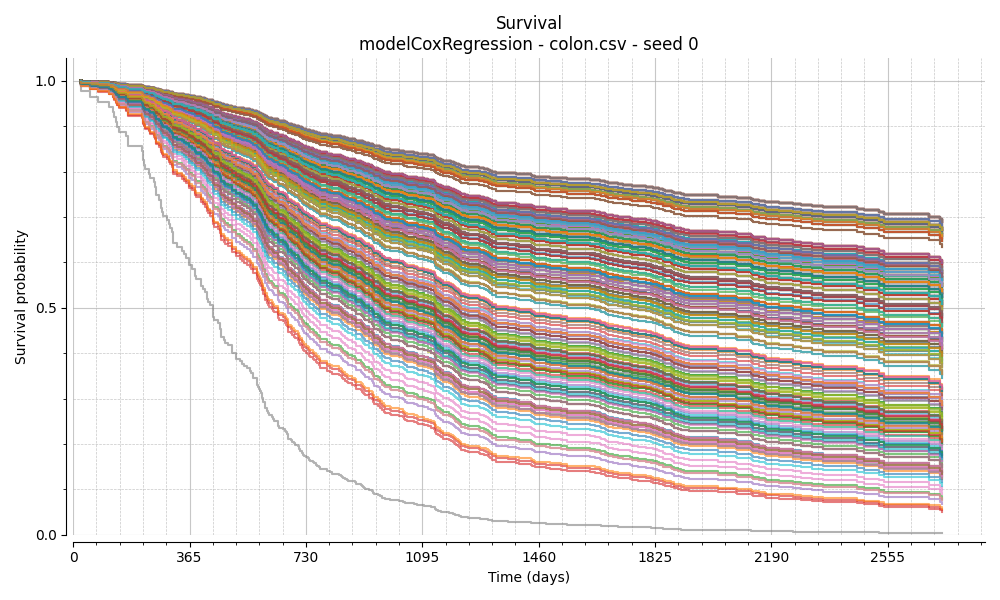

In [9]:
survival_function = modelCoxRegression.predict_survival_function(X=X_train_standard, index=train_idx, estimator_name="modelCoxRegression", dataset="colon.csv", seed=0, plot=True)

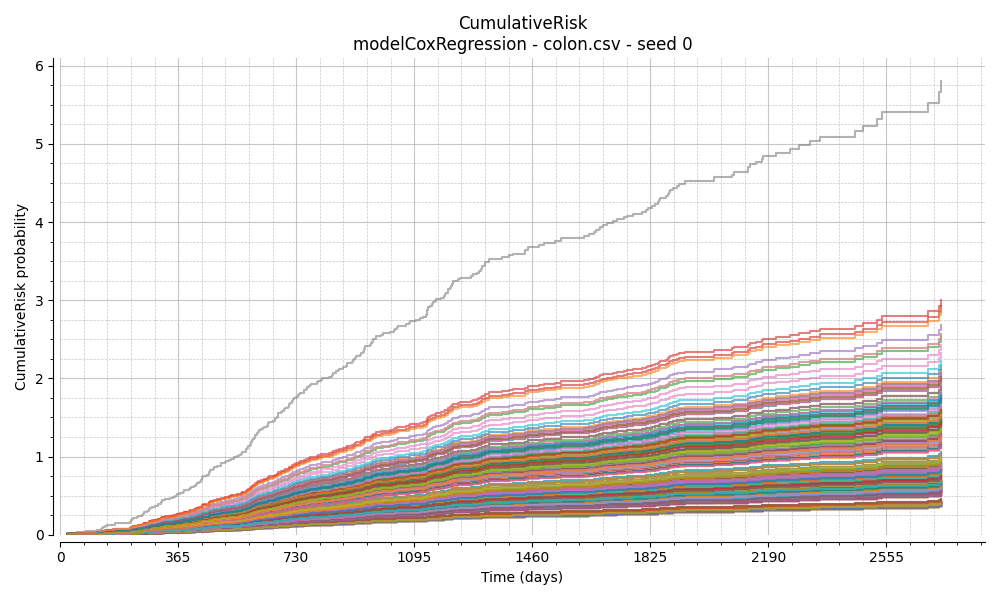

In [10]:
cumulative_hazard_function = modelCoxRegression.predict_cumulative_hazard_function(X=X_train_standard, index=train_idx, estimator_name="modelCoxRegression", dataset="colon.csv", seed=0, plot=True)

### eXplainable Artificial Intelligence

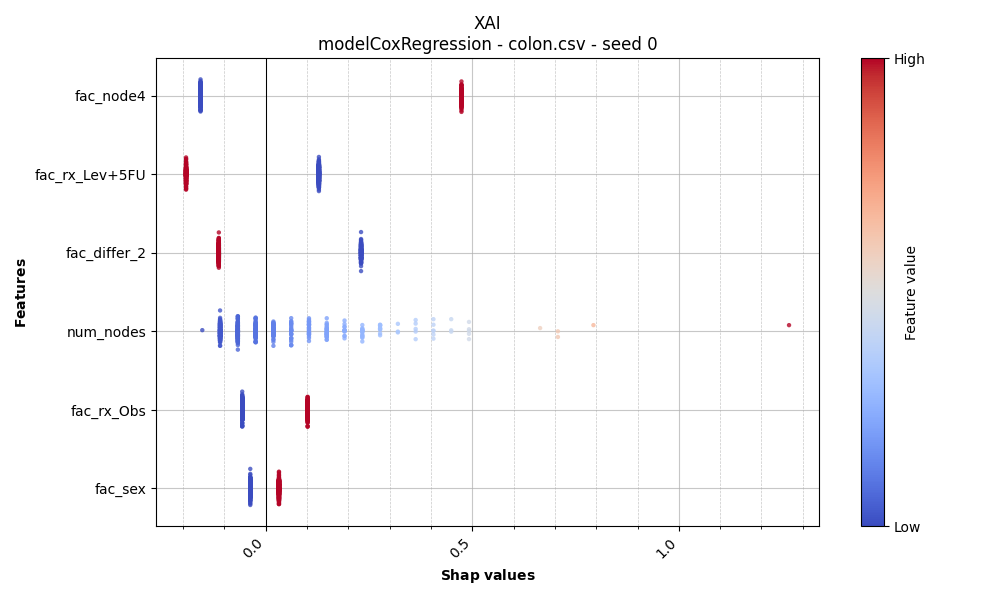

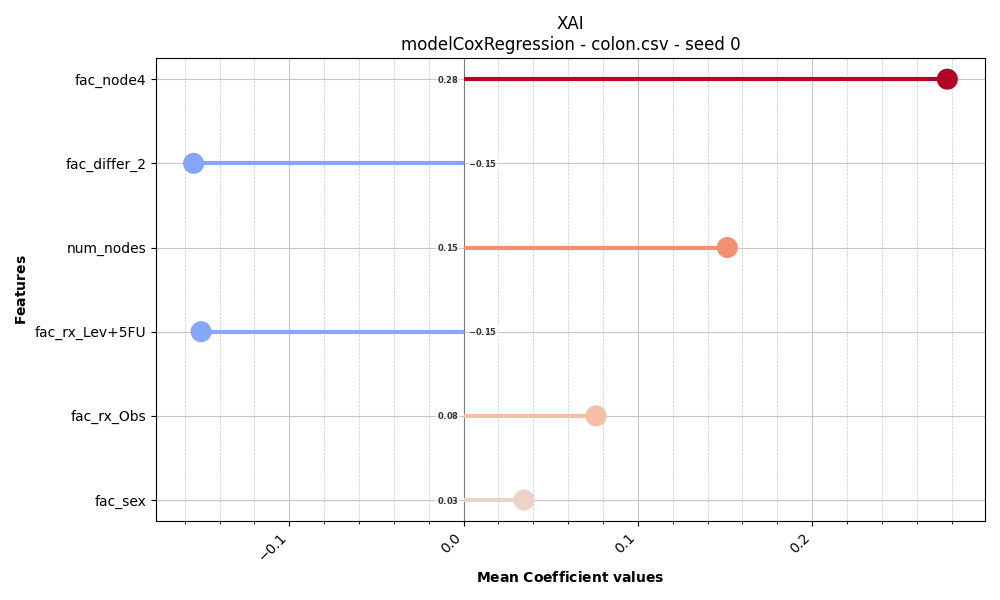

In [11]:
shap_explainer, coefficients = modelCoxRegression.calculate_xai(X=X_train_standard, index=train_idx, scaler=scaler, estimator_name="modelCoxRegression", dataset="colon.csv", seed=0, feature_names=feature_names, background=None, plot=True)

## Survival analysis (multitask)

### Get data

In [12]:
X_train, y_train, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(dataset_name="colon.csv", to_multitask=True)


- - - - colon.csv (csv) - - - -

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   event         911 non-null    int64  
 1   time          911 non-null    int64  
 2   num_age       911 non-null    int64  
 3   num_nodes     911 non-null    float64
 4   fac_rx        911 non-null    object 
 5   fac_sex       911 non-null    int64  
 6   fac_differ    911 non-null    object 
 7   fac_obstruct  911 non-null    int64  
 8   fac_perfor    911 non-null    int64  
 9   fac_adhere    911 non-null    int64  
 10  fac_node4     911 non-null    int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 78.4+ KB

             event         time     num_age   num_nodes fac_rx     fac_sex  \
count   911.000000   911.000000  911.000000  911.000000    911  911.000000   
unique         NaN          NaN         NaN         NaN      3         NaN   
top 

### Instantiate models

In [13]:
modelDeepMultiTask = DeepMultiTask(X_train.shape[1])

### Fit and predict

In [14]:
modelDeepMultiTask = modelDeepMultiTask.fit(X_train, y_train)
survPredDeepMultiTask = modelDeepMultiTask.predict(X_test)

### Metrics

In [15]:
compute_survival_metrics(y_train, y_test, survPredDeepMultiTask)

{'C-Index Harrel': 0.49870596092836866,
 'C-Index IPCW': 0.5040953026556166,
 'Cumulative Dinamic AUC': [0.5043254205789616,
  0.47200720407993524,
  0.4920275782916415]}

### Survival / Cumulative Hazard Functions

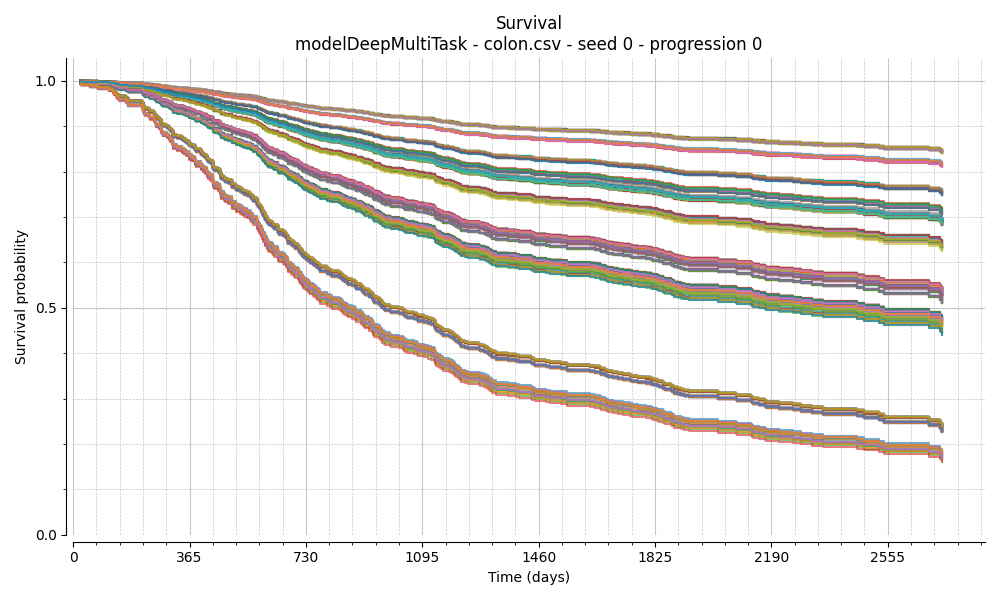

In [16]:
survival_function = modelDeepMultiTask.predict_survival_function(X=X_train, index=train_idx, estimator_name="modelDeepMultiTask", dataset="colon.csv", seed=0, plot=True)

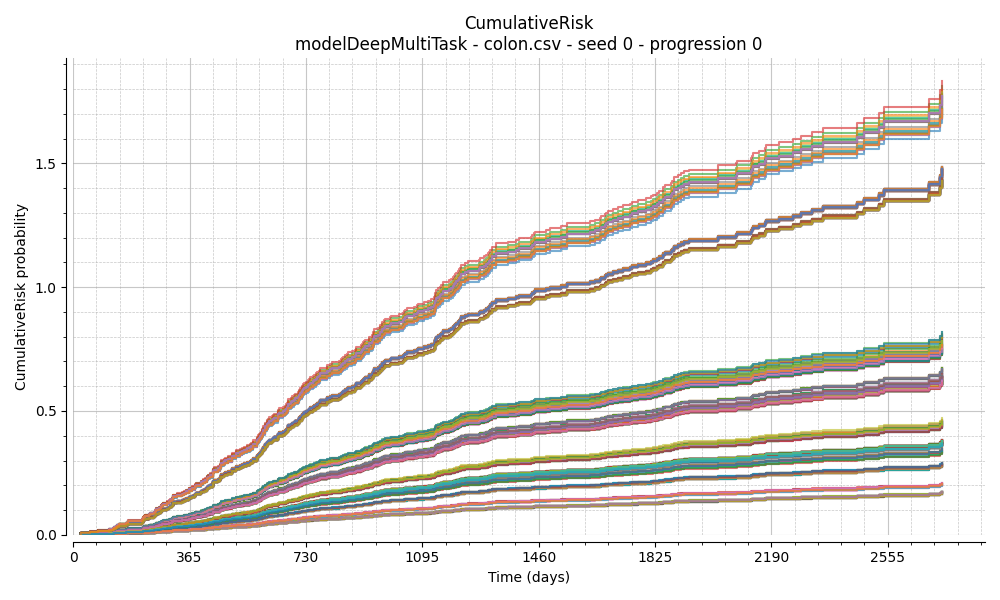

In [17]:
cumulative_hazard_function = modelDeepMultiTask.predict_cumulative_hazard_function(X=X_train, index=train_idx, estimator_name="modelDeepMultiTask", dataset="colon.csv", seed=0, plot=True)

### eXplainable Artificial Intelligence

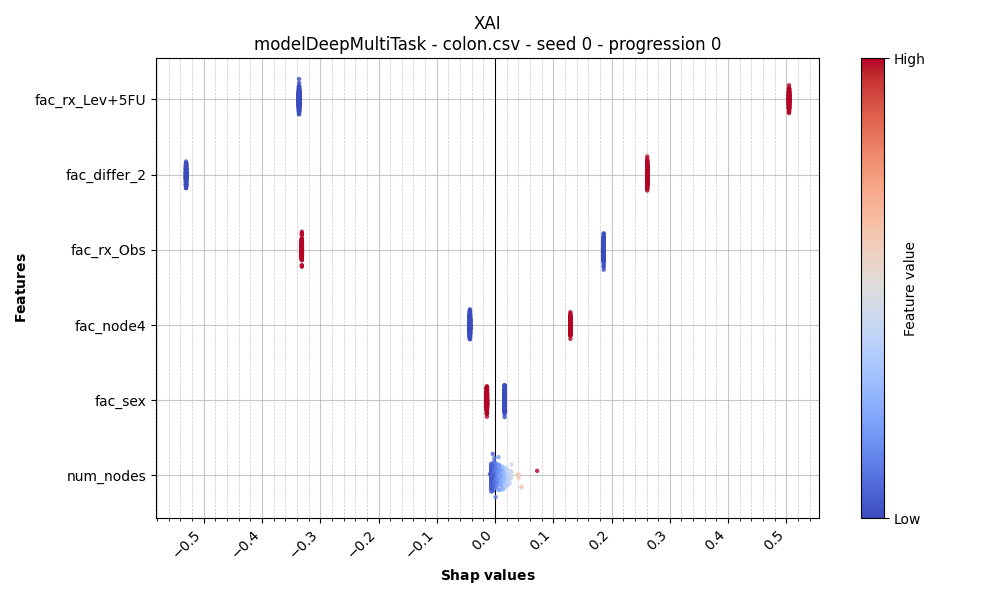

In [18]:
shap_explainer = modelDeepMultiTask.calculate_xai(X=X_train, index=train_idx, scaler=scaler, estimator_name="modelDeepMultiTask", dataset="colon.csv", seed=0, feature_names=feature_names, background=None, plot=True)

## Survival analysis (time varying)

In [13]:
df = pd.read_csv("./MATRIX/datasets/colon.csv")

### Find splits dynamically

In [14]:
splits = BaseSurvival.dinamic_discretise(y=df[["time", "event"]], dataset="colon", seed=0, plot=False)

In [15]:
df["identifier"] = df.index.values

### Transform to time varying format

In [16]:
df = BaseSurvival.to_time_dependent(dataframe=df, splits=splits, identifier="identifier", time="time", event="event")

In [17]:
df = BaseSurvival.to_time_varying(dataframe=df, identifier="identifier", time="time", event="event")

### Get data

In [18]:
X_train, y_train, X_validation, y_validation, X_test, y_test, train_idx, val_idx, test_idx, feature_names, scaler = get_data(df=df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4049 entries, 0 to 4048
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   identifier    4049 non-null   int64  
 1   num_age       4049 non-null   int64  
 2   num_nodes     4049 non-null   float64
 3   fac_rx        4049 non-null   object 
 4   fac_sex       4049 non-null   int64  
 5   fac_differ    4049 non-null   object 
 6   fac_obstruct  4049 non-null   int64  
 7   fac_perfor    4049 non-null   int64  
 8   fac_adhere    4049 non-null   int64  
 9   fac_node4     4049 non-null   int64  
 10  event         4049 non-null   int64  
 11  time_start    4049 non-null   float64
 12  time_stop     4049 non-null   float64
dtypes: float64(3), int64(8), object(2)
memory usage: 411.4+ KB

         identifier      num_age    num_nodes   fac_rx      fac_sex  \
count   4049.000000  4049.000000  4049.000000     4049  4049.000000   
unique          NaN          NaN         

### Instantiate models

In [ ]:
modelCoxRegressionWithTimeVarying = CoxRegressionWithTimeVarying()
modelDeepTimeVarying = DeepTimeVarying(X_train.shape[1])

### Fit and predict

In [ ]:
modelCoxRegressionWithTimeVarying = modelCoxRegressionWithTimeVarying.fit(X_train, y_train)
modelDeepTimeVarying = modelDeepTimeVarying.fit(X_train, y_train)

survPredCoxRegressionWithTimeVarying = modelCoxRegressionWithTimeVarying.predict(X_test)
survPredDeepTimeVarying = modelDeepTimeVarying.predict(X_test)

### Metrics

In [ ]:
compute_survival_metrics(y_train, y_test, survPredCoxRegressionWithTimeVarying)

{'C-Index Harrel': 0.6355955375697254,
 'C-Index IPCW': 0.6332035502395869,
 'Cumulative Dinamic AUC': [0.6363646563838035,
  0.6488692045509804,
  0.6189078114020805]}

In [28]:
compute_survival_metrics(y_train, y_test, survPredDeepTimeVarying)

{'C-Index Harrel': 0.4520534835393197,
 'C-Index IPCW': 0.3892677216819816,
 'Cumulative Dinamic AUC': [0.4558377354928641,
  0.42579531986589203,
  0.38118963086729063]}

### Survival / Cumulative Hazard Functions

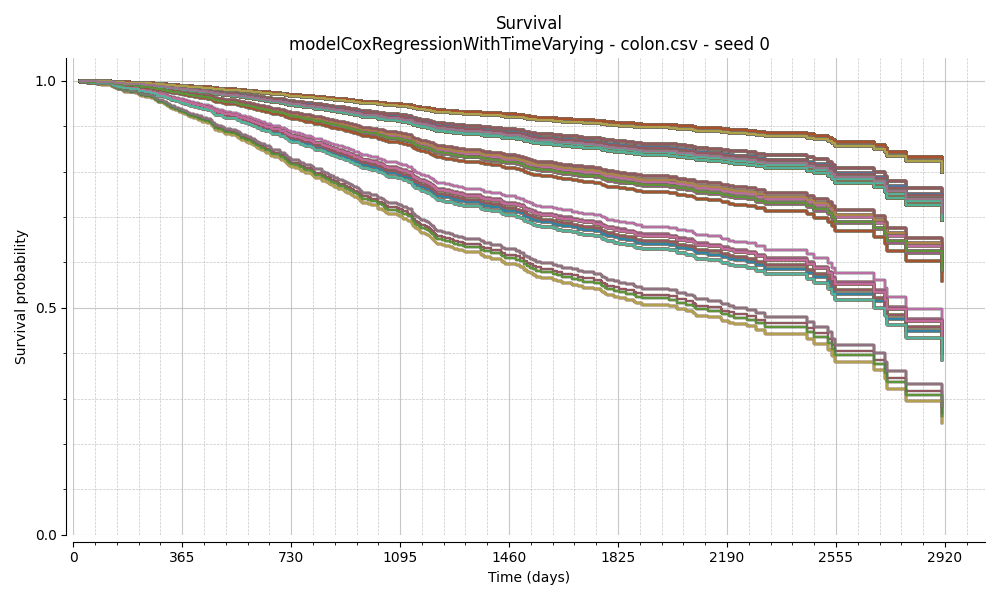

In [29]:
survival_function = modelCoxRegressionWithTimeVarying.predict_survival_function(X=X_train, index=train_idx, estimator_name="modelCoxRegressionWithTimeVarying", dataset="colon.csv", seed=0, plot=True)

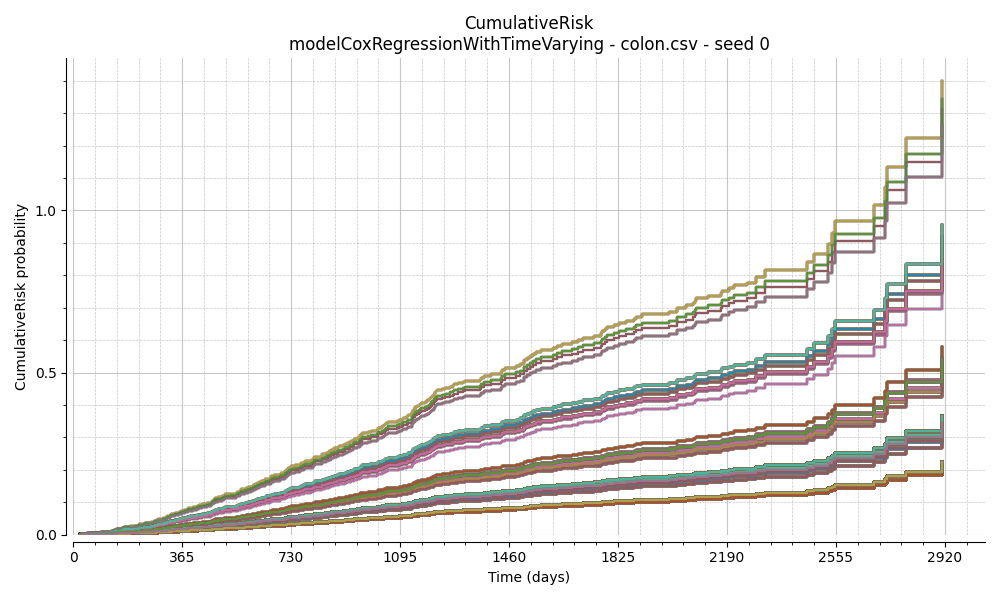

In [30]:
cumulative_hazard_function = modelCoxRegressionWithTimeVarying.predict_cumulative_hazard_function(X=X_train, index=train_idx, estimator_name="modelCoxRegressionWithTimeVarying", dataset="colon.csv", seed=0, plot=True)

### eXplainable Artificial Intelligence

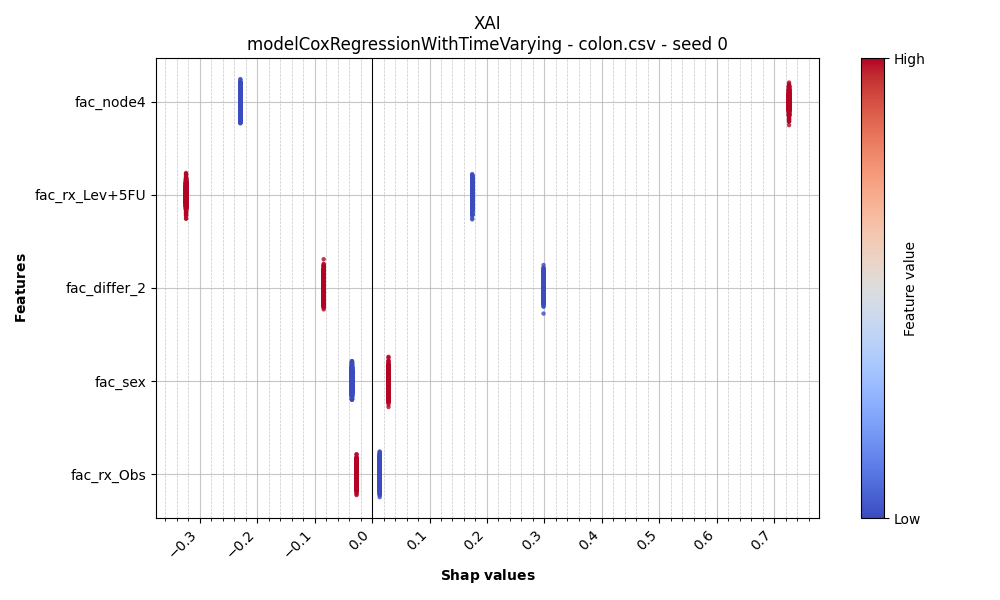

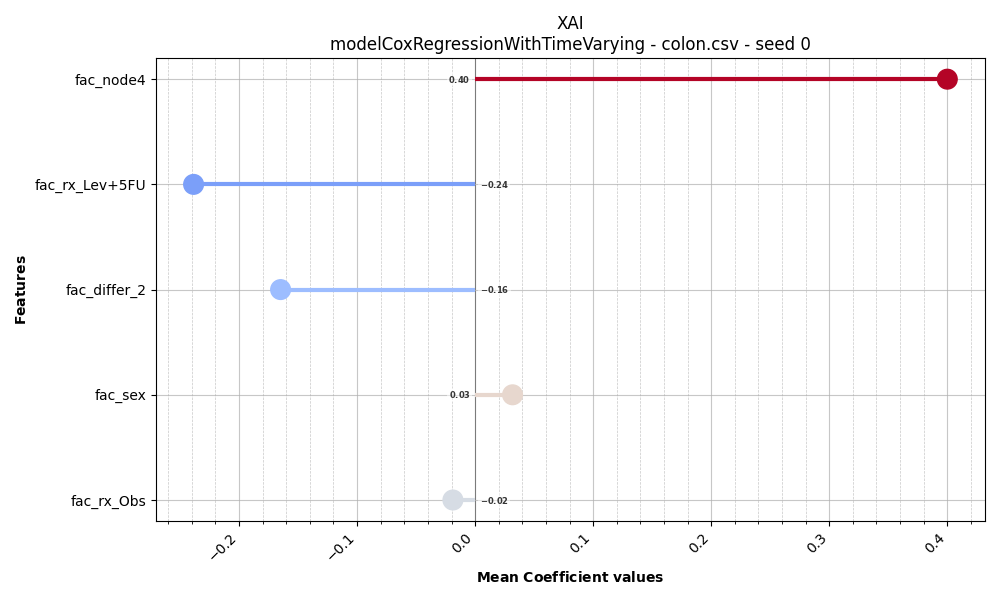

In [31]:
shap_explainer, coefficients = modelCoxRegressionWithTimeVarying.calculate_xai(X=X_train, index=train_idx, scaler=scaler, estimator_name="modelCoxRegressionWithTimeVarying", dataset="colon.csv", seed=0, feature_names=feature_names, background=None, plot=True)

## Tools

### Feature selector

In [32]:
features_selected = BaseSurvival.feature_selection(X_train_standard, y_train_standard)

In [33]:
print(f"ALL FEATURES: {X_train_standard.shape}, SELECTED FEATURES: {X_train_standard[:, features_selected].shape}")

ALL FEATURES: (582, 6), SELECTED FEATURES: (582, 4)


### Simulated survival data

In [34]:
BaseSurvival.generate_simulated_survival_data(number_rows=1000, number_columns=10, censored=0.75, relation="sin", seed=0)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,event,time
0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219,0.410599,0,7.39
1,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158,0.313068,-0.854096,1,82.31
2,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759,-0.187184,1.532779,1.469359,1,5.16
3,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349,1.230291,1.202380,-0.387327,-0.302303,1,3.00
4,-1.048553,-1.420018,-1.706270,1.950775,-0.509652,-0.438074,-1.252795,0.777490,-1.613898,-0.212740,0,2.93
...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.622801,1.240477,0.170446,1.986898,0.111301,1.209655,-0.457330,0.923183,1.325519,-0.953166,0,0.53
996,-0.678130,0.334100,-0.754928,-0.388383,-0.626576,-1.306421,-0.038496,0.143567,-0.789074,-0.098504,0,0.09
997,-1.452866,-0.947866,-0.869579,-0.305517,-0.605147,0.224821,-1.038472,0.771819,-0.480009,1.834745,0,0.06
998,-0.108765,0.454475,0.098709,-0.458305,-0.857044,-0.774403,0.708787,0.018474,-0.104081,-0.234858,0,0.33


### Log-rank test

In [35]:
identifier = np.arange(len(X_train_standard))

In [36]:
# H0 = "There is no difference in the survival curves between the groups analysed" (p-value < threshold ==> reject H0)
BaseSurvival.logrank_test(y_train_standard, identifier)

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 581
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        3459.80 <0.005       inf

# Results

## Show stored results

In [ ]:
results = get_results(result_folder="./results", estimator_name="CoxRegression", dataset=None)
#results = get_results(estimator_name="CoxRegressionWithTimeVarying", dataset="cgd.csv")
#results = get_results(estimator_name="DeepMultiTaskFFNN", dataset="colon.csv")

In [9]:
for i, result in enumerate(results):
    print(f"Result {i}:\n")
    print(f"    * Estimator: {result.config['estimator_name']} - Dataset: {result.config['dataset']} - Seed: {result.config['random_state']}")
    print(f"    * Best Params: {result.data_.best_params}")
    print()
    print(f"    * Metrics: {compute_metrics(result.data_.train_targets[1], result.data_.targets[1], result.data_.predictions)}")
    print("\n\n")

Result 0:

    * Estimator: CoxRegression - Dataset: gbsg.h5 - Seed: 0
    * Best Params: {'ties': 'breslow', 'n_iter': 100, 'alpha': 1.0}

    * Metrics: {'C-Index Harrel': 0.6938387053985939, 'C-Index IPCW': 0.6704027975012259, 'Cumulative Dinamic AUC': [0.7291107810236861, 0.7625411578004475, 0.7512101833317005]}



Result 1:

    * Estimator: CoxRegression - Dataset: gbsg.h5 - Seed: 1
    * Best Params: {'ties': 'efron', 'n_iter': 100, 'alpha': 0.1}

    * Metrics: {'C-Index Harrel': 0.6597062289111456, 'C-Index IPCW': 0.6472270535386964, 'Cumulative Dinamic AUC': [0.7611283188130057, 0.6974166494536391, 0.6729026283913823]}



Result 2:

    * Estimator: CoxRegression - Dataset: gbsg.h5 - Seed: 2
    * Best Params: {'ties': 'breslow', 'n_iter': 100, 'alpha': 1.0}

    * Metrics: {'C-Index Harrel': 0.6524154589371981, 'C-Index IPCW': 0.6559479178892473, 'Cumulative Dinamic AUC': [0.7258099581474011, 0.7224147305163817, 0.7484219288193676]}



Result 3:

    * Estimator: CoxRegressi

## Plot XAI results 

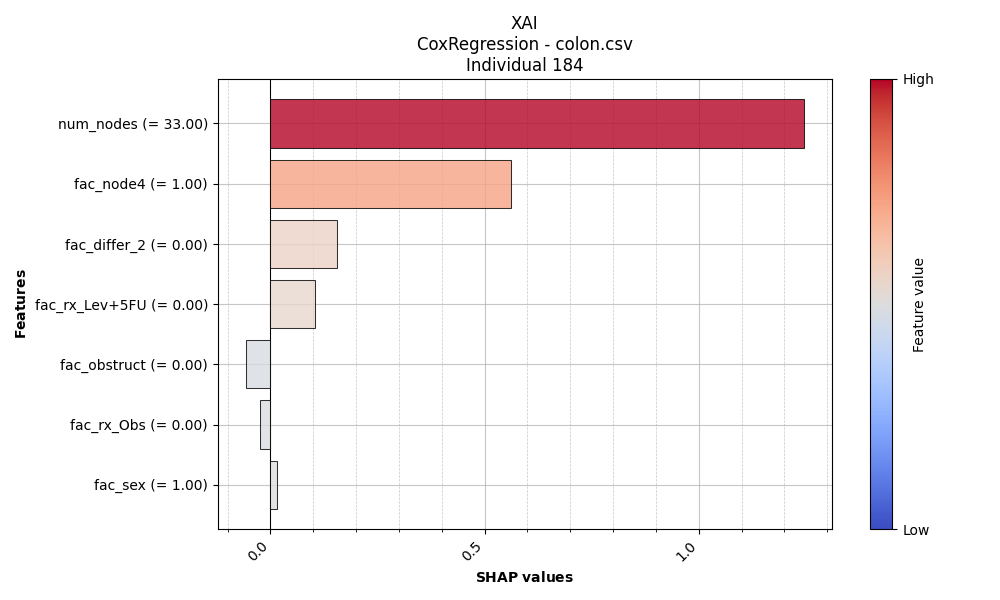

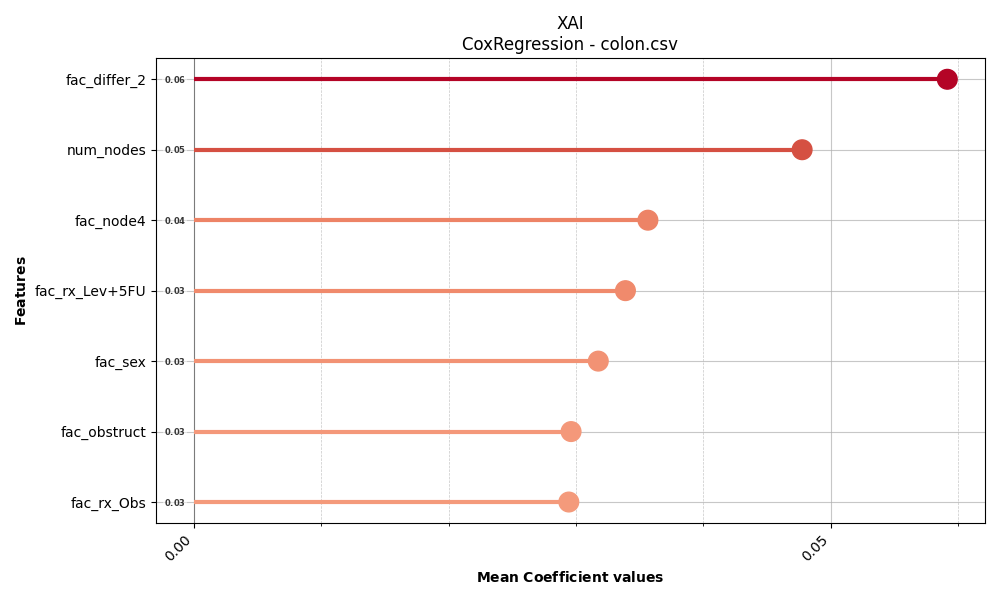

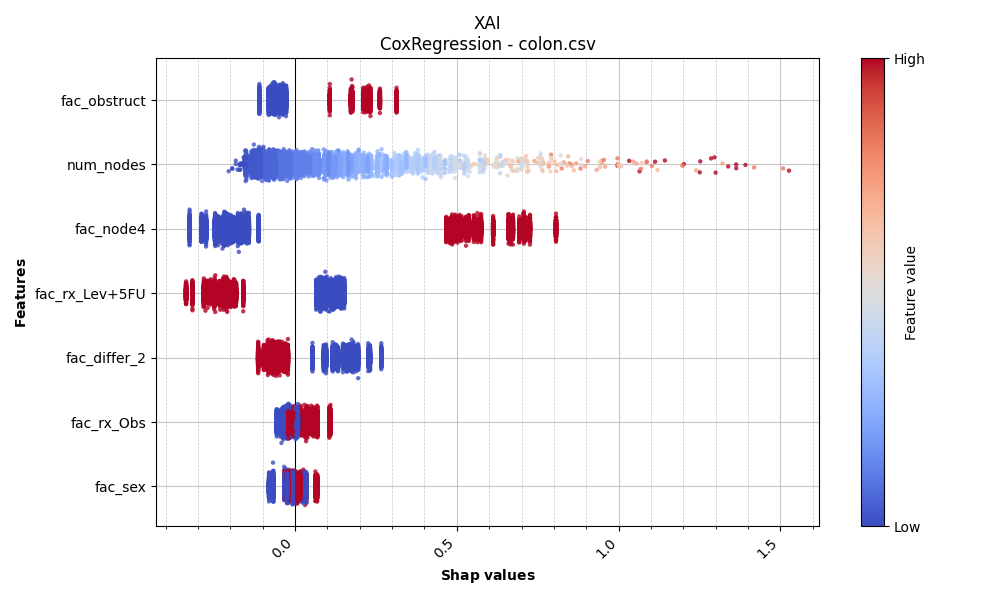

In [ ]:
get_xai_from_filter(result_folder="./results", estimator_name="CoxRegression", dataset="colon.csv", seed=None, identifier_index=184)
#get_xai(estimator_name="CoxRegression", dataset="colon.csv")
#get_xai(dataset="colon.csv")

## Save stored results 

In [16]:
save_results(result_folder="./results", estimator_name="CoxRegression", dataset=None)